# **03 - Deep Learning / Neural Network**

This notebook constructs a neural network model based on classification data which contains 13,611 observations and 16 features. The dataset categorizes one of 7 dry bean types based on measurements with the following encoding:

- 0 DERMASON    3546
- 1 SIRA        2636
- 2 SEKER       2027
- 3 HOROZ       1928
- 4 CALI        1630
- 5 BARBUNYA    1322
- 6 BOMBAY       522

The training, validation, and test splits were calculated using an 80/20 split resulting in:

- Training: 8710
- Validation: 2178
- Test: 2723

Datasets splits were stratified to maintain proportionality.

Dataset: https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

## ****Libraries****

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import copy

## **Data Loading**

In [19]:
df = pd.read_excel('datasets/Dry_Bean_Dataset.xlsx')

### **Data Split**

In [20]:
# Training+Validation / Test Split
train_val_df, test_df = train_test_split(
    df,
    test_size = 0.20, # 80% training+validation / 20% test
    random_state = 79,
    stratify = df['Class']
)

# Training / Validation Split
train_df, val_df = train_test_split(
    train_val_df,
    test_size = 0.20, # 80% training / 20% validation
    random_state = 85,
    stratify = train_val_df['Class']
)
# Proportion Verification
print("Training proportions:")
print(train_df['Class'].value_counts(normalize=True))

print("\nValidation proportions:")
print(val_df['Class'].value_counts(normalize=True))

print("\nTest proportions:")
print(test_df['Class'].value_counts(normalize=True))

# Data Shape
print("-----------------------")
print(f"Training Data Shape: {train_df.shape}")
print(f"\nValidation Data Shape: {val_df.shape}")
print(f"\nTest Data Shape: {test_df.shape}")

# X / Y Split
x_train_df = train_df.drop(columns=['Class']) # Drops column containing y data
y_train_df = train_df['Class'] # Column contains y

x_val_df = val_df.drop(columns=['Class']) # Drops column containing y data
y_val_df = val_df['Class'] # Column contains y

x_test_df = test_df.drop(columns=['Class']) # Drops column containing y data
y_test_df = test_df['Class'] # Column contains y

print("-----------------------")
print("--Post X/Y Split Shape--")
print(f"\nTraining x: {x_train_df.shape}")
print(f"\nValidation x: {x_val_df.shape}")
print(f"\nTest x: {x_test_df.shape}")
print(f"\nTraining y: {y_train_df.shape}")
print(f"\nValidation y: {y_val_df.shape}")
print(f"\nTest y: {y_test_df.shape}")

# Convert Y to:
# DERMASON --> 0
# SIRA     --> 1
# SEKER    --> 2
# HOROZ    --> 3
# CALI     --> 4
# BARBUNYA --> 5
# BOMBAY   --> 6

y_train_df = y_train_df.map({
    'DERMASON' : 0,
    'SIRA' : 1,
    'SEKER' : 2,
    'HOROZ' : 3,
    'CALI' : 4,
    'BARBUNYA' : 5,
    'BOMBAY' : 6
})

y_val_df = y_val_df.map({
    'DERMASON' : 0,
    'SIRA' : 1,
    'SEKER' : 2,
    'HOROZ' : 3,
    'CALI' : 4,
    'BARBUNYA' : 5,
    'BOMBAY' : 6
})

y_test_df = y_test_df.map({
    'DERMASON' : 0,
    'SIRA' : 1,
    'SEKER' : 2,
    'HOROZ' : 3,
    'CALI' : 4,
    'BARBUNYA' : 5,
    'BOMBAY' : 6
})


Training proportions:
Class
DERMASON    0.260505
SIRA        0.193685
SEKER       0.148909
HOROZ       0.141676
CALI        0.119747
BARBUNYA    0.097130
BOMBAY      0.038347
Name: proportion, dtype: float64

Validation proportions:
Class
DERMASON    0.260790
SIRA        0.193756
SEKER       0.148760
HOROZ       0.141414
CALI        0.119835
BARBUNYA    0.096878
BOMBAY      0.038567
Name: proportion, dtype: float64

Test proportions:
Class
DERMASON    0.260375
SIRA        0.193537
SEKER       0.149100
HOROZ       0.141755
CALI        0.119721
BARBUNYA    0.097319
BOMBAY      0.038193
Name: proportion, dtype: float64
-----------------------
Training Data Shape: (8710, 17)

Validation Data Shape: (2178, 17)

Test Data Shape: (2723, 17)
-----------------------
--Post X/Y Split Shape--

Training x: (8710, 16)

Validation x: (2178, 16)

Test x: (2723, 16)

Training y: (8710,)

Validation y: (2178,)

Test y: (2723,)


### **Feature Scaling**

In [21]:
# Feature Scaling
x_train_mean = x_train_df.mean()
x_train_std = x_train_df.std()

x_train_scaled = (x_train_df - x_train_mean) / x_train_std
x_val_scaled = (x_val_df - x_train_mean) / x_train_std
x_test_scaled = (x_test_df - x_train_mean) / x_train_std

# Check Scaling
print(x_train_scaled.mean())
print(x_train_scaled.std())

Area              -1.301166e-16
Perimeter          3.809684e-16
MajorAxisLength    2.398388e-16
MinorAxisLength   -3.002063e-16
AspectRation       1.063571e-15
Eccentricity       2.174049e-16
ConvexArea        -9.789337e-18
EquivDiameter      7.794760e-16
Extent             4.568357e-17
Solidity          -1.879879e-14
roundness         -1.202049e-15
Compactness       -3.038773e-16
ShapeFactor1       3.709751e-16
ShapeFactor2      -2.920486e-16
ShapeFactor3      -5.159797e-17
ShapeFactor4      -1.462853e-14
dtype: float64
Area               1.0
Perimeter          1.0
MajorAxisLength    1.0
MinorAxisLength    1.0
AspectRation       1.0
Eccentricity       1.0
ConvexArea         1.0
EquivDiameter      1.0
Extent             1.0
Solidity           1.0
roundness          1.0
Compactness        1.0
ShapeFactor1       1.0
ShapeFactor2       1.0
ShapeFactor3       1.0
ShapeFactor4       1.0
dtype: float64


### **Tensor Conversion**

In [29]:
# Convert data into Tensor Data
x_train = torch.tensor(x_train_scaled.values, dtype=torch.float32)
y_train = torch.tensor(y_train_df.values, dtype=torch.long)

x_val = torch.tensor(x_val_scaled.values, dtype=torch.float32)
y_val = torch.tensor(y_val_df.values, dtype=torch.long)

x_test = torch.tensor(x_test_scaled.values, dtype=torch.float32)
y_test = torch.tensor(y_test_df.values, dtype=torch.long)

# Check Shape
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

torch.Size([8710, 16]) torch.Size([8710])
torch.Size([2178, 16]) torch.Size([2178])
torch.Size([2723, 16]) torch.Size([2723])


## **Model**

### **Model Architecture**

In [50]:
# Neural Network Architecture
class DNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.neural_stack = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU(),
            nn.Linear(32, 7)
        )

    def forward(self, data):
        logits = self.neural_stack(data)
        return logits

# Instance, Loss Function, Optimizer
model = DNN(16) # Specify number of features
loss_function = nn.CrossEntropyLoss() # <--- Cross-entropy loss for multiclass classification
optimizer = torch.optim.SGD(model.parameters(),lr=1e-2) # Stochastic Grad. Descent

### **Model Training and Validation**

epoch =  0  training loss =  1.04383385181427  validation loss =  1.0480139255523682  difference =  0.0041800737380981445
epoch =  200  training loss =  0.17805923521518707  validation loss =  0.21485526859760284  difference =  0.03679603338241577
epoch =  400  training loss =  0.17016877233982086  validation loss =  0.21138057112693787  difference =  0.041211798787117004
epoch =  600  training loss =  0.1657603681087494  validation loss =  0.20868800580501556  difference =  0.042927637696266174
epoch =  800  training loss =  0.1627759337425232  validation loss =  0.20756107568740845  difference =  0.044785141944885254


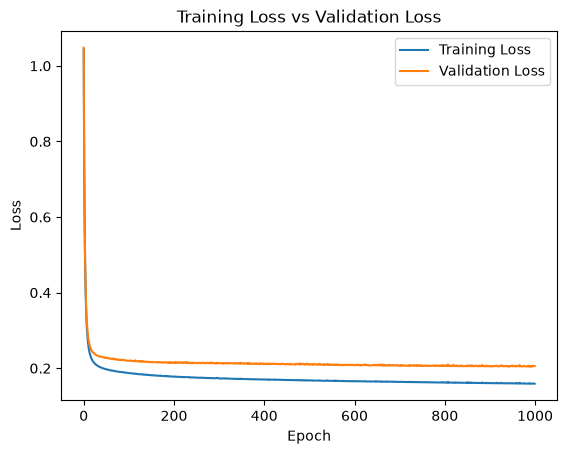

Training Accuracy: 0.939
Validation Accuracy: 0.931
Best epoch: 943, Best validation loss: 0.2042056918144226


In [51]:
loss_list = []
val_loss_list = []
training_accuracy_list = []
val_accuracy_list =[] # Unused - Keeping as may plot

best_val_loss = float('inf')
best_weights = None
best_epoch = None

nums_epoch = 1000 # Epoch is one complete pass through the training set

merged_training = TensorDataset(x_train, y_train)
train_loader = DataLoader(merged_training, batch_size=32, shuffle=True)

for epoch in range(nums_epoch):

    for x_batch, y_batch in train_loader:

        prediction = model(x_batch) # Takes x training data, produces new y_hat with current parameters
        loss = loss_function(prediction, y_batch) # Cost/Loss function calculation

        # Gradient Descent
        optimizer.zero_grad() # Clear current gradient information
        loss.backward() # Backprop - calculate partial derivatives based on current loss with respect to each contributing parameter
        optimizer.step() # Calculate the new weights based on step/learning rate

    with (torch.no_grad()):

        # Training loss for the completed epoch
        train_prediction = model(x_train)
        train_loss = loss_function(train_prediction, y_train)
        loss_list.append(train_loss.item())

        # Training accuracy for the completed epoch
        train_class = torch.argmax(train_prediction, dim=1) # Largest logit assigned to class. Returns class.
        training_correct = (train_class == y_train) # Boolean comparison
        training_accuracy = training_correct.sum().item() / len(training_correct)
        training_accuracy_list.append(training_accuracy)

        # Validation loss and accuracy for the completed epoch
        val_prediction = model(x_val)
        val_loss = loss_function(val_prediction, y_val)
        val_loss_list.append(val_loss.item())

        # Validation accuracy for the completed epoch
        val_class = torch.argmax(val_prediction, dim=1) # Largest logit assigned to class. Returns class.
        val_correct = (val_class == y_val) # Boolean comparison with predictions vs actual
        val_accuracy = val_correct.sum().item() / len(val_correct)
        val_accuracy_list.append(val_accuracy)

        # Best Weights Tracking
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        # Print out of Epoch performance
        if epoch % 200 == 0:
            print('epoch = ', epoch,
                    ' training loss = ', train_loss.item(),
                    ' validation loss = ', val_loss.item(),
                    ' difference = ',
                  abs(train_loss.item()-val_loss.item())
            )

# Training Loss vs Validation Loss Plot
plt.plot(loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#-------------------------------------------
# Final Training / Validation Evaluation
# Using best validation weights
#-------------------------------------------

assert best_weights is not None
model.load_state_dict(best_weights)

model.eval()

with torch.no_grad():

    # Training predictions using best weights
    train_prediction = model(x_train)
    train_loss = loss_function(train_prediction, y_train)

    train_class = torch.argmax(train_prediction, dim=1)
    training_correct = (train_class == y_train)
    training_accuracy = (
        training_correct.sum().item()
        / len(training_correct)
    )

    # Validation predictions using best weights
    val_prediction = model(x_val)
    val_loss = loss_function(val_prediction, y_val)

    val_class = torch.argmax(val_prediction, dim=1)
    val_correct = (val_class == y_val)
    val_accuracy = (
        val_correct.sum().item()
        / len(val_correct)
    )

# Report Out

print(f"Training Accuracy: {round(training_accuracy, 3)}")
print(f"Validation Accuracy: {round(val_accuracy, 3)}")

print(
    f"Best epoch: {best_epoch}, "
    f"Best validation loss: {best_val_loss}"
)


##### _Confusion Matrix_

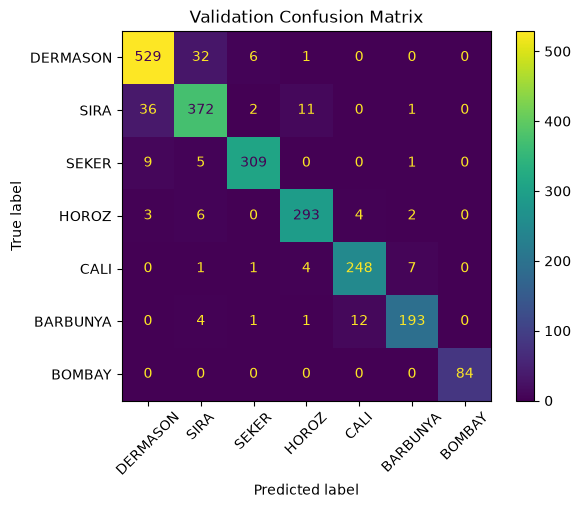

In [53]:
# Class names in the same order as your numerical encoding
class_names = [
    'DERMASON',
    'SIRA',
    'SEKER',
    'HOROZ',
    'CALI',
    'BARBUNYA',
    'BOMBAY'
]

# Build confusion matrix
cm = confusion_matrix(y_val.numpy(), val_class.numpy())

# Plot
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot()
plt.xticks(rotation=45)
plt.title('Validation Confusion Matrix')
plt.show()

### **Model Testing and Results**

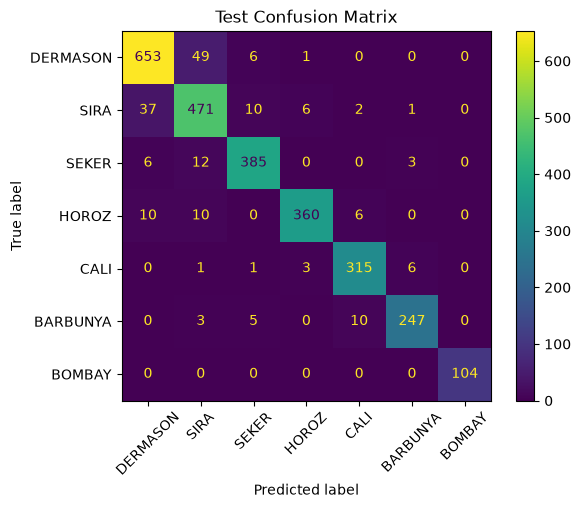

Test Loss =  0.20682311058044434
Test Accuracy: 0.931


In [54]:
assert best_weights is not None
model.load_state_dict(best_weights)

model.eval()

with torch.no_grad():
    test_prediction = model(x_test)
    test_loss = loss_function(test_prediction, y_test)

    # Test accuracy
    test_class = torch.argmax(test_prediction, dim=1) # Largest logit assigned to class. Returns class.
    test_correct = (test_class == y_test) # Boolean comparison with predictions vs actual
    test_accuracy = test_correct.sum().item() / len(test_correct)

# Test Confusion Matrix

# Class names in the same order as your numerical encoding
class_names = [
    'DERMASON',
    'SIRA',
    'SEKER',
    'HOROZ',
    'CALI',
    'BARBUNYA',
    'BOMBAY'
]

# Build confusion matrix
cm = confusion_matrix(y_test.numpy(), test_class.numpy())

# Plot
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot()
plt.xticks(rotation=45)
plt.title('Test Confusion Matrix')
plt.show()


# Report Out
print("Test Loss = ", test_loss.item())
print(f"Test Accuracy: {round(test_accuracy, 3)}")


Seven model configurations were evaluated by varying network width, depth, activation function, and batch size. Despite these changes, validation accuracy remained within a narrow range of approximately 92.5–93.0%, suggesting that the tested architectural changes and batch sizes were not major drivers of model performance. The baseline architecture was retained and, after retraining, achieved 93.9% training accuracy, 93.1% validation accuracy, and 93.1% test accuracy. The close validation and test results suggest that the model generalized well to unseen data. Examination of the confusion matrices showed that the largest concentration of classification errors occurred between the SIRA and DERMASON classes, with a smaller cluster between CALI and BARBUNYA. Further improvement would therefore likely require investigation of the underlying feature distributions rather than simply increasing network complexity.